## Loading package

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import STCOGAT
import warnings
from STCOGAT.Utils import *
from STCOGAT.data_preprocess import *
import matplotlib.pyplot as plt
import anndata as ad
import os
os.environ['R_HOME'] = '/usr/lib/R'


warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=300,fontsize=10,dpi_save=300,facecolor='white',format='pdf')
plt.rcParams.update({'axes.titlesize': 20})
sc.settings.figdir = './Result/mouse_breast/'
outdir = './Result/mouse_breast/'
os.makedirs(outdir, exist_ok=True)

cuda:0


## Reading ST data and showing two sections of mouse brain data

In [ ]:
# read data
file_fold = './data/'
adata = sc.read_h5ad(file_fold + 'mouse_breast_cancer_sample1_section1&2.h5ad')
adata.var_names_make_unique()

In [7]:
adata

AnnData object with n_obs × n_vars = 3818 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'data'
    obsm: 'spatial'

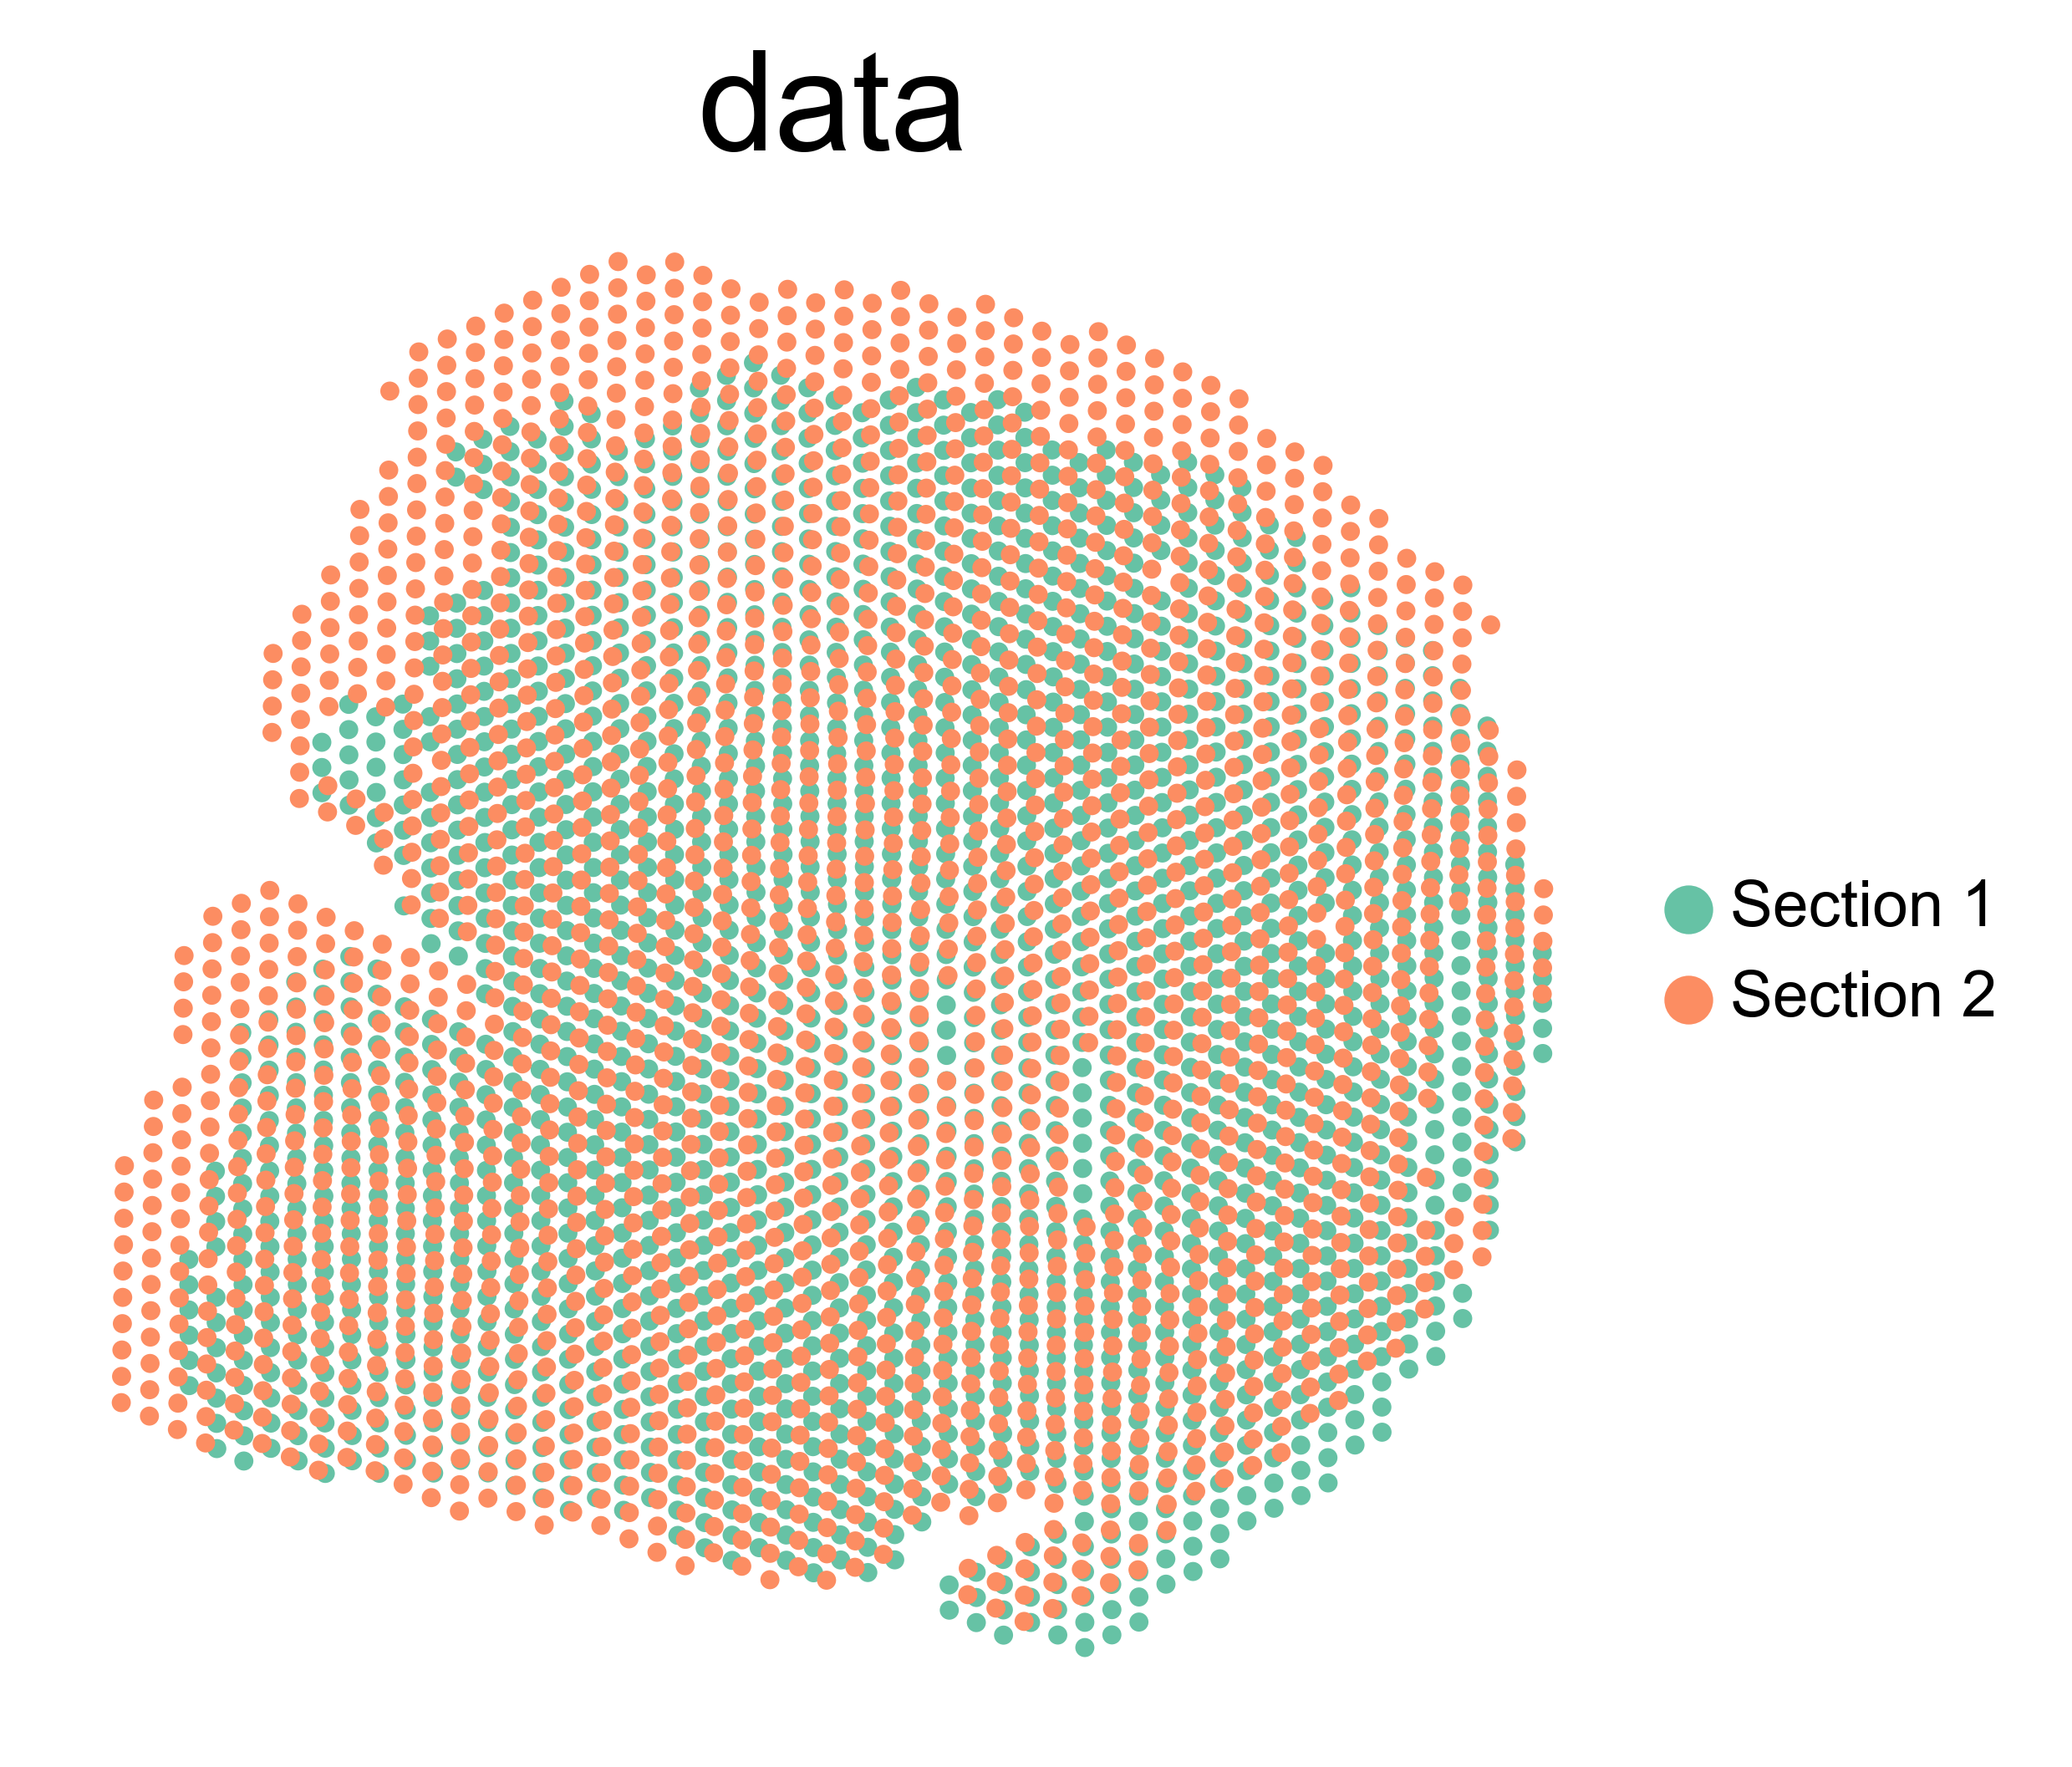

In [ ]:
plt.rcParams["figure.figsize"] = (4, 4)
adata.obsm['spatial'][:, 1] = -1*adata.obsm['spatial'][:, 1]
adata.obs['data'].replace({'S1':'Section 1', 'S3':'Section 2'}, inplace=True)
import seaborn as sns
palette = sns.color_palette("Set2", n_colors=adata.obs['data'].nunique())

ax = sc.pl.embedding(adata, basis='spatial', color='data', s=30, show=False,frameon=False,palette=palette)
# ax.set_title('Aligned image')
plt.savefig(
    outdir+'BC_Batch.pdf',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',  
    edgecolor='white'  
)

In [ ]:
STCOGAT.main.INTER_DIM = 256 
STCOGAT.main.EMBEDDING_DIM = 26
STCOGAT.main.DE_GENES_NUM = 2000
STCOGAT.main.pre_emb_dim = 14
STCOGAT.main.lamba_smooth = 0.2
STCOGAT.main.lambda_contra = 0.2

sc.pp.filter_genes(adata, min_cells=3)
ad, adata_raw = svg(adata, svg_method='seurat_v3', n_top=2000)

## Training the model

In [ ]:
adata = ad.copy()
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=15)  
net, genet, node_feature = STCOGAT.build_coexpres_network(adata, topk=20)
print('genet:',genet,'node_feature:',node_feature.shape)
knn_edge_index = STCOGAT.build_fused_graph(adata,alpha=0.5,k_spat=6,knn_method='KNN',rad_cutoff=150, prune=True)
print('Initial knn_edge_index:', knn_edge_index.shape)
STCOGAT.run_STCOGAT(adata, genet,node_feature,knn_edge_index, number_of_batches=1,max_epoch=600, model_name ="mouse_breast",save_model_flag=True)

_, embedded_cells, node_features , out_features = STCOGAT.load_embeddings("mouse_breast")
adata.obsm['embed'] = embedded_cells

In [ ]:
adata = STCOGAT.mclust_R(adata, num_cluster=10, modelNames='EEE', used_obsm='embed',random_seed=2,obs_key='mclust_labels')

In [23]:
import harmonypy as hm
from sklearn.metrics import silhouette_score, davies_bouldin_score

batchkl = BatchKL(adata,batch_column='data')[0]
print(f'BatchKL: {batchkl:.3f}')

ILISI = hm.compute_lisi(adata.obsm['embed'], adata.obs[['data']], label_colnames=['data'])[:, 0]
median_ILISI = np.median(ILISI)
print(f'Median ILISI: {median_ILISI:.3f}')


BatchKL = 0.12980284937976147
BatchKL: 0.130
Median ILISI: 1.868


In [ ]:
adata = STCOGAT.mclust_R(adata, num_cluster=10, modelNames='EEE', used_obsm='embed',random_seed=18,obs_key='mclust_labels')
SC = silhouette_score(adata.obsm['embed'], adata.obs['mclust_labels'])
DB = davies_bouldin_score(adata.obsm['embed'], adata.obs['mclust_labels'])
print('SC:', SC)
print('DB:', DB)

SC: 0.214
DB: 1.348


## Visualization

### Batch effect removal figure

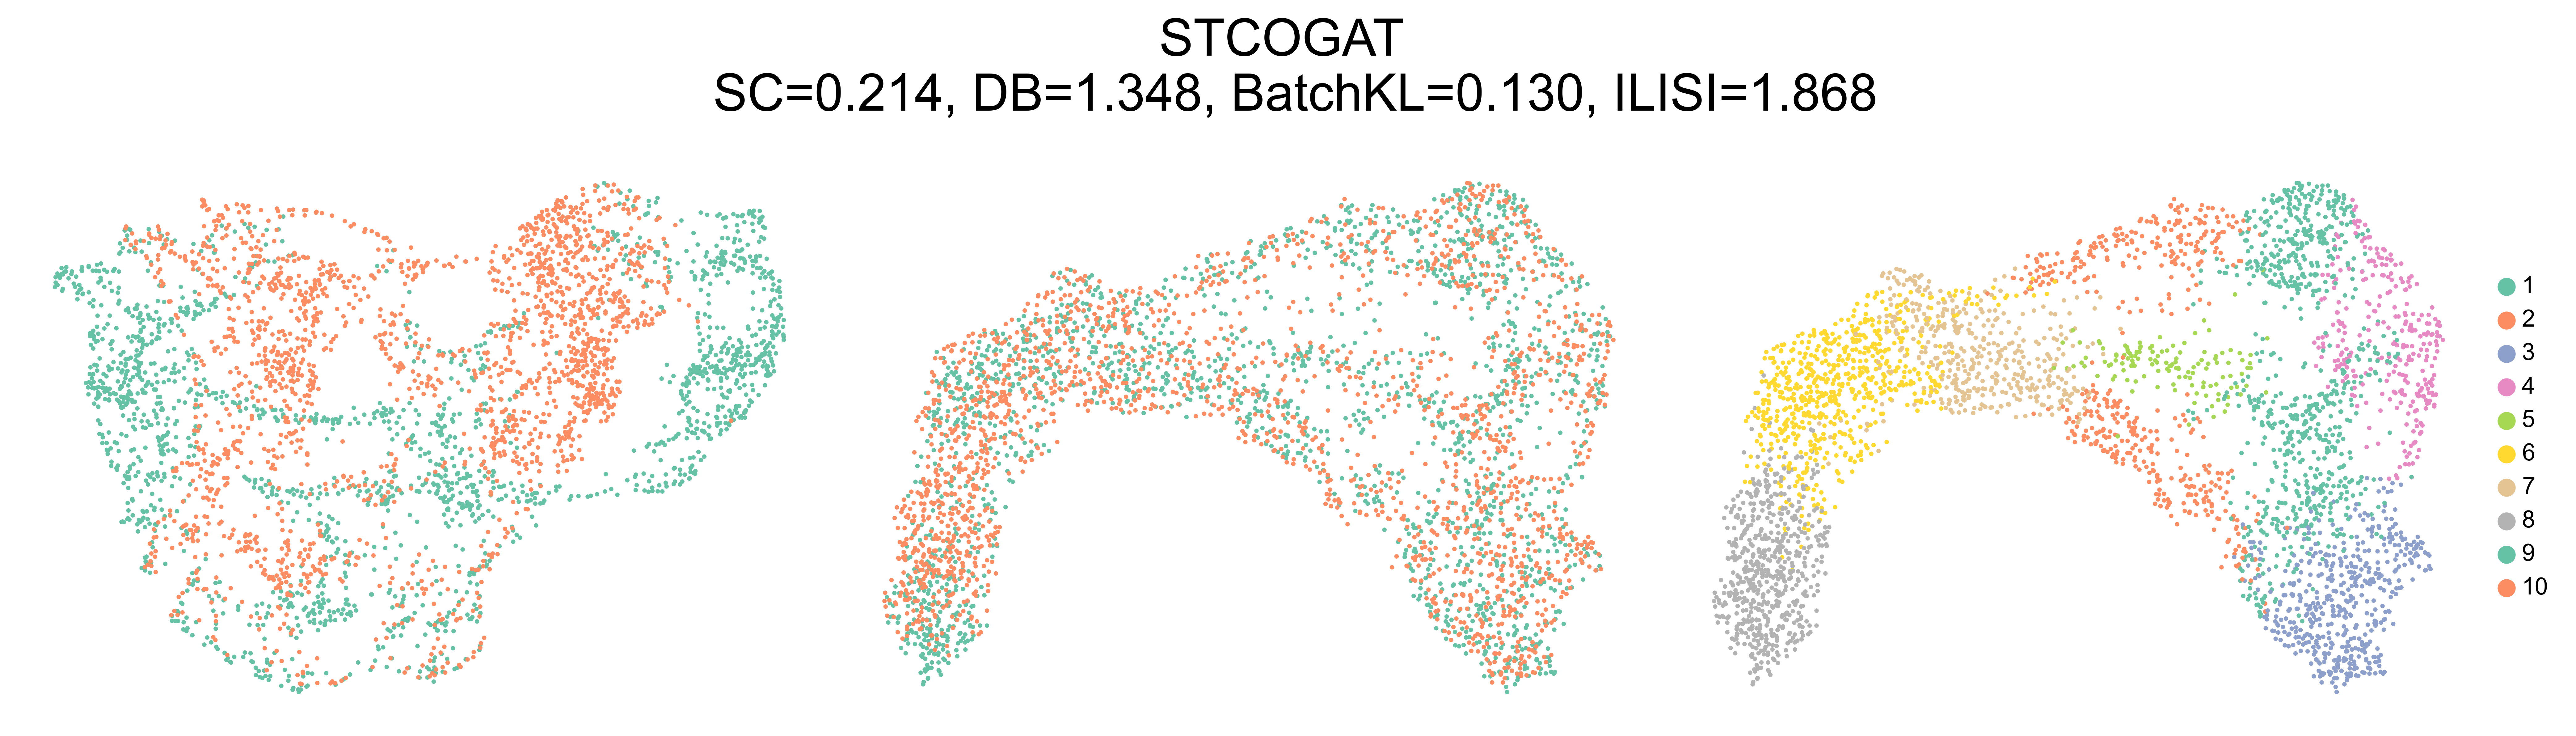

In [ ]:
import seaborn as sns

cats = adata.obs['data'].astype('category').cat.categories
rgb_values = sns.color_palette("Set2", len(cats))
color_fine = dict(zip(cats, rgb_values))

cats = adata.obs['mclust_labels'].astype('category').cat.categories
rgb_values = sns.color_palette("Set2", len(cats))
color_fine2 = dict(zip(cats, rgb_values))

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, ax_list = plt.subplots(1, 3, figsize=(14, 4), facecolor='white')

sc.pp.neighbors(adata, use_rep='X_pca', metric='cosine')
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color='data',
    title=' ',
    ax=ax_list[0],
    show=False,
    palette=color_fine,
    s=12,
    frameon=False,
    legend_loc=None
)

sc.pp.neighbors(adata, use_rep='embed', n_neighbors=10)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color='data',
    ax=ax_list[1],
    title=' ',
    show=False,
    palette=color_fine,
    s=12,
    frameon=False,
    legend_loc=None
)

sc.pl.umap(
    adata,
    color='mclust_labels',
    ax=ax_list[2],
    title=' ',
    show=False,
    palette=color_fine2,
    s=12,
    frameon=False
)

for ax in ax_list:
    ax.set_facecolor('white')

fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.suptitle(
    f'STCOGAT \n SC={SC:.3f}, DB={DB:.3f}, BatchKL={batchkl:.3f}, ILISI={median_ILISI:.3f}',
    ha='center',  
    va='top',    
    fontsize=20   
)
plt.savefig(
    outdir + 'BC_Batch_umap.pdf',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',  
    edgecolor='white'   
)

plt.show()

### Spatial clustering for two sections

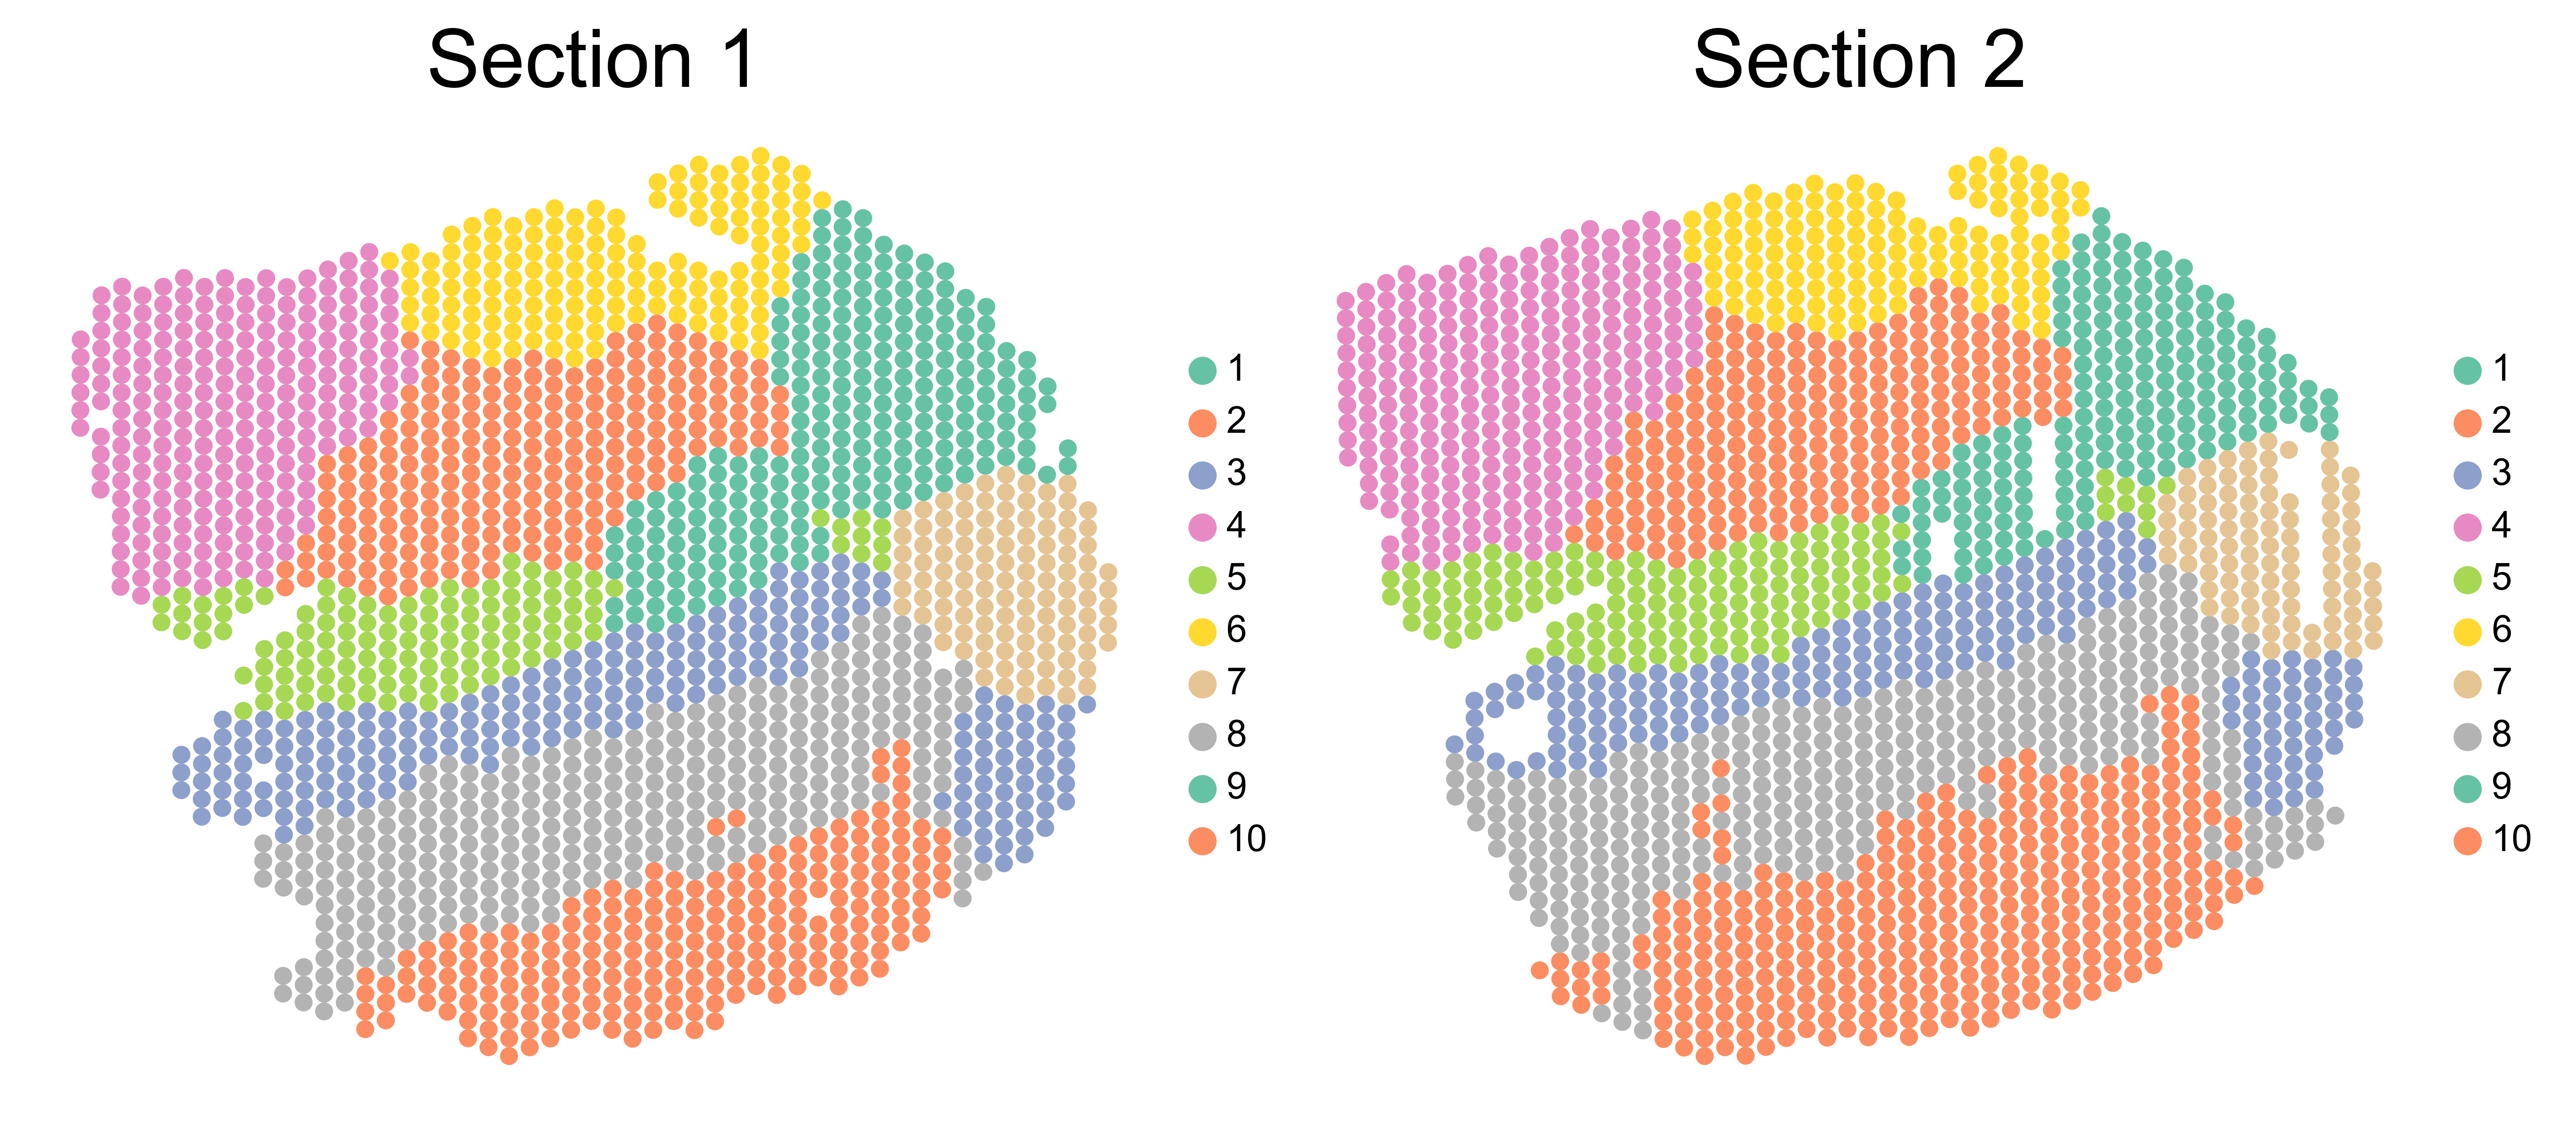

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

adata_section1 = adata[adata.obs['data'] == 'Section 1', :].copy()
adata_section2 = adata[adata.obs['data'] == 'Section 2', :].copy()

cats = adata.obs['mclust_labels'].astype('category').cat.categories
rgb_values = sns.color_palette("Set2", len(cats))
color_fine = dict(zip(cats, rgb_values))

fig, ax_list = plt.subplots(1, 2, figsize=(9, 4))

sc.pl.embedding(
    adata_section1,
    basis='spatial',
    color='mclust_labels',
    size=80,
    title='Section 1',
    palette=color_fine,
    frameon=False,    
    show=False,
    ax=ax_list[0],
)

sc.pl.embedding(
    adata_section2,
    basis='spatial',
    color='mclust_labels',
    size=80,
    title='Section 2',
    palette=color_fine,
    frameon=False,     
    show=False,
    ax=ax_list[1],
)

plt.tight_layout(w_pad=0.3)
plt.savefig(outdir + 'BC_Batch_spatial.pdf', dpi=300, bbox_inches='tight', facecolor='white')
